# OmniSearch — Baseline Coordination Comparison

Loads the most recent `results/baseline_comparison_*.json` and visualises:

1. Mean ± std table per strategy
2. Bar charts of the four numeric metrics — survivor recall, time-to-verification, hazard exposure, UGV travel cost
3. A roll-up reading of *which strategy each metric prefers*

**Prerequisite:** run the comparison harness first.

```bash
python scripts/compare_baselines.py --seeds 5 --steps 200
```

**Note on noise:** these numbers come from hand-coded baselines on a *random* fire seed. With only a few seeds the differences are noisy; re-run with `--seeds 10+` for cleaner signal.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('..') / 'results'
files = sorted(RESULTS_DIR.glob('baseline_comparison_*.json'))
if not files:
    raise FileNotFoundError(
        f'No baseline_comparison_*.json in {RESULTS_DIR.resolve()}.\n'
        'Run: python scripts/compare_baselines.py'
    )
latest = files[-1]
print(f'Loading: {latest.name}')
rows = json.loads(latest.read_text())
df = pd.DataFrame(rows)
print(f'Strategies: {df["strategy"].tolist()}')
print(f'Seeds:      {df["seeds"].iloc[0]}')
print(f'Steps:      {df["steps"].iloc[0]}')

Loading: baseline_comparison_1779849596.json
Strategies: ['random', 'lawnmower', 'nearest_candidate', 'highest_confidence']
Seeds:      3
Steps:      200


## 1. Summary table

All six metrics side-by-side. Recall and DRR-style metrics are higher-is-better; ttv, hazard, travel cost are lower-is-better.

In [2]:
summary = pd.DataFrame({
    'strategy':       df['strategy'],
    'recall (↑)':     df['survivor_recall_mean'].apply(lambda v: f'{v:.2f}'),
    'recall_std':     df['survivor_recall_std'].apply(lambda v: f'±{v:.2f}'),
    'ttv (↓)':        df['time_to_verification'].apply(lambda v: f'{v:.1f}' if v == v else '—'),
    'hazard (↓)':     df['hazard_exposure_mean'].apply(lambda v: f'{v:.0f}'),
    'ugv_dist (↓)':   df['ugv_travel_cost_mean'].apply(lambda v: f'{v:.2f}'),
}).set_index('strategy')
summary

,recall (↑),recall_std,ttv (↓),hazard (↓),ugv_dist (↓)
strategy,,,,,
random,0.00,±0.00,—,0,1.11
lawnmower,0.27,±0.12,154.3,0,1.76
nearest_candidate,0.33,±0.12,169.0,0,1.77
highest_confidence,0.00,±0.00,—,0,3.33


## 2. Bar charts — one per metric

Direction arrows tell you which way better lies.

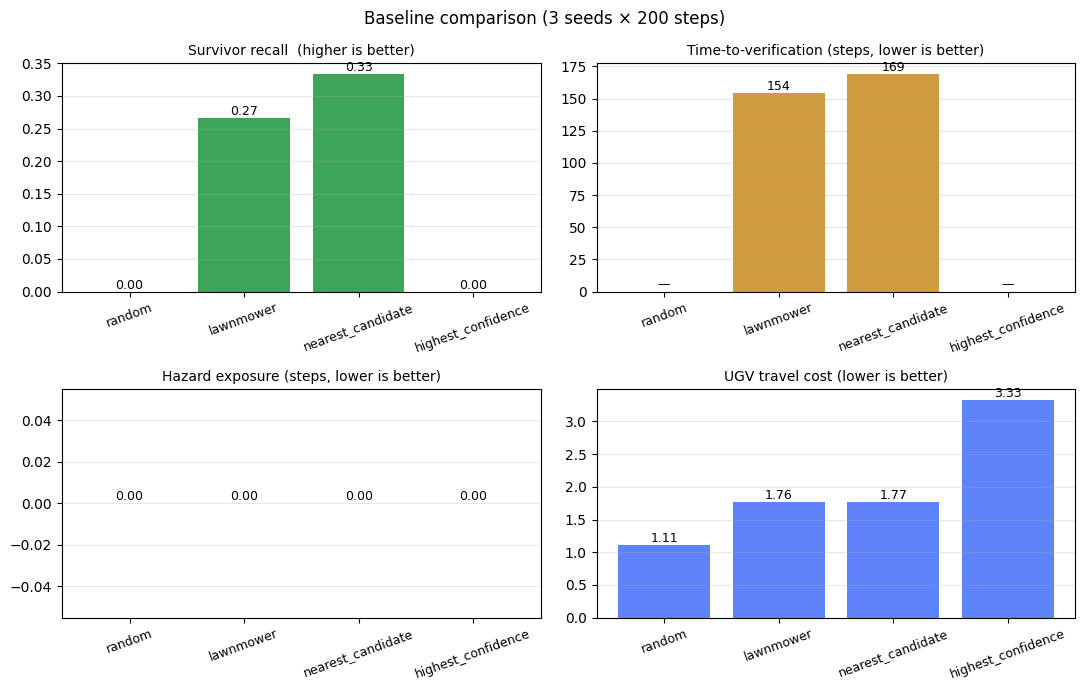

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
labels = df['strategy'].tolist()

panels = [
    ('survivor_recall_mean', 'Survivor recall  (higher is better)', axes[0, 0], '#3da45a'),
    ('time_to_verification', 'Time-to-verification (steps, lower is better)', axes[0, 1], '#d09a3e'),
    ('hazard_exposure_mean', 'Hazard exposure (steps, lower is better)', axes[1, 0], '#d04848'),
    ('ugv_travel_cost_mean', 'UGV travel cost (lower is better)', axes[1, 1], '#5d82fa'),
]
for col, title, ax, color in panels:
    vals = df[col].values
    # Replace NaN with 0 just for plotting; we'll annotate '—' on those bars.
    plot_vals = [0 if v != v else v for v in vals]
    bars = ax.bar(labels, plot_vals, color=color)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=20, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        label = '—' if v != v else (f'{v:.2f}' if v < 10 else f'{v:.0f}')
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                label, ha='center', va='bottom', fontsize=9)
fig.suptitle(f'Baseline comparison ({df["seeds"].iloc[0]} seeds × {df["steps"].iloc[0]} steps)',
             fontsize=12)
plt.tight_layout()
plt.show()

## 3. Per-metric winners

For each metric, which strategy was best across the seeds in this comparison? The HAPPO/MAPPO entry will be added once a trained policy is loadable.

In [4]:
directions = {
    'survivor_recall_mean':  'max',
    'time_to_verification':  'min',
    'hazard_exposure_mean':  'min',
    'ugv_travel_cost_mean':  'min',
}
names = {
    'survivor_recall_mean': 'Survivor recall (↑)',
    'time_to_verification': 'Time-to-verification (↓)',
    'hazard_exposure_mean': 'Hazard exposure (↓)',
    'ugv_travel_cost_mean': 'UGV travel cost (↓)',
}
print(f'{"Metric":28s} {"Winner":22s} {"Value":>8s}')
print('-' * 60)
for col, direction in directions.items():
    vals = df[col]
    if vals.dropna().empty:
        print(f'{names[col]:28s} {"(no data)":22s} {"—":>8}')
        continue
    if direction == 'max':
        idx = vals.idxmax()
    else:
        idx = vals.idxmin()
    print(f'{names[col]:28s} {df.loc[idx, "strategy"]:22s} {vals.loc[idx]:>8.2f}')

Metric                       Winner                    Value
------------------------------------------------------------
Survivor recall (↑)          nearest_candidate          0.33
Time-to-verification (↓)     lawnmower                154.33
Hazard exposure (↓)          random                     0.00
UGV travel cost (↓)          random                     1.11


## Next steps

1. Bump `--seeds 10` (or more) when running `compare_baselines.py` to tighten the std bands
2. Once a `--research`-budget MAPPO/IPPO run is committed and saves a checkpoint, add a `trained:path` entry to the baseline registry and re-run — the comparison will show whether learned coordination beats `nearest_candidate` (33% recall in the smoke run)
3. Re-export trajectories (`python scripts/export_trajectories.py`) and open the React + Three.js viewer at `http://localhost:8080` to see the strategies side-by-side visually